<!-- CONCLUSION-CELL -->
> ## ✅ 결론 — 최적 X구간: **pitch15 (초반 15구)**
>
> | 구간 | XGB Val R² | CB Val R² | 비고 |
> |---|---|---|---|
> | pitch10 | 0.0768 | **0.0888** | RMSE 최소 |
> | **pitch15** ⭐ | **0.0824** | 0.0861 | XGB R² 최고 · 정보량 더 많음 |
> | pitch20 | 0.0732 | 0.0867 | |
> | batter9 (baseline) | 0.0780 | 0.0837 | |
>
> - RMSE 최소는 pitch10이나, **XGB R² 최고는 pitch15(0.0824)**.
> - 초반 15구(약 3~4타자)로 이후 헛스윙률 예측 → 실용성·정보량 균형.
> - **→ 이후 모든 실험은 pitch15 고정.**


# 06. X 구간 실험
- 05_nan_experiment 완료 후 실행
- starters_all.parquet + prev_season_lookup.parquet → 구간별 feature 생성
- 각 구간별 XGBoost/CatBoost 성능 비교

| 실험 | mode | n |
|---|---|---|
| E3-1 | pitch | 10 |
| E3-2 | pitch | 15 |
| E3-3 | pitch | 20 |
| E3-4 | inning | 1 |
| E3-5 | inning | 2 |
| E3-6 | batter | 3 |
| E3-7 | batter | 6 |
| E3-8 | batter | 9 (baseline) |

---

## 실험 결과 요약

| 실험 | mode | n | XGB Val RMSE | XGB Val R² | CB Val RMSE | CB Val R² |
|---|---|---|---|---|---|---|
| E3-1 pitch10 | pitch | 10 | **0.0834** | 0.0768 | **0.0828** | **0.0888** |
| **E3-2 pitch15** | pitch | 15 | 0.0851 | **0.0824** | 0.0849 | 0.0861 |
| E3-3 pitch20 | pitch | 20 | 0.0873 | 0.0732 | 0.0867 | 0.0867 |
| E3-4 inning1 | inning | 1 | 0.0861 | 0.0784 | 0.0858 | 0.0850 |
| E3-5 inning2 | inning | 2 | 0.0965 | 0.0654 | 0.0960 | 0.0745 |
| E3-6 batter3 | batter | 3 | 0.0844 | 0.0783 | 0.0841 | 0.0844 |
| E3-7 batter6 | batter | 6 | 0.0860 | 0.0755 | 0.0855 | 0.0851 |
| E3-8 batter9 | batter | 9 | 0.0885 | 0.0780 | 0.0883 | 0.0837 |

### 최적 X 구간 확정: **pitch15**

| 기준 | 자동 선택 | 최종 확정 | 근거 |
|---|---|---|---|
| RMSE 최소 | pitch10 | pitch15 | XGB R² 최고 (0.0824), 정보량 더 많음 |

> **결론**: RMSE 기준 최적은 pitch10이나, XGB R² 기준 pitch15가 최고(0.0824).  
> 초반 15구(약 3~4타자) 데이터로 이후 헛스윙률 예측. 이후 모든 실험은 **pitch15 고정**.

In [1]:
# ── 환경 감지 ──────────────────────────────────────────────
import os, sys

IN_COLAB = 'google.colab' in str(get_ipython())

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    DRIVE = '/content/drive/MyDrive/투수 컨디션 예측 ML'
    NB_DIR = os.path.join(DRIVE, '3_modeling')
    sys.path.insert(0, NB_DIR)
else:
    DRIVE  = os.path.dirname(os.path.abspath('__file__'))
    NB_DIR = os.path.dirname(os.path.abspath('__file__'))

INTERIM_DIR  = os.path.join(DRIVE, '0_data', '2_interim')
FEATURE_DIR  = os.path.join(DRIVE, '0_data', '4_features')
OUTPUT_DIR   = os.path.join(DRIVE, '4_output')
STARTERS     = os.path.join(INTERIM_DIR, 'starters_all.parquet')
LOOKUP       = os.path.join(INTERIM_DIR, 'prev_season_lookup.parquet')
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f'환경: {"코랩" if IN_COLAB else "로컬"}')
print(f'STARTERS: {STARTERS}')
print(f'LOOKUP  : {LOOKUP}')

Mounted at /content/drive
환경: 코랩
STARTERS: /content/drive/MyDrive/투수 컨디션 예측 ML/0_data/2_interim/starters_all.parquet
LOOKUP  : /content/drive/MyDrive/투수 컨디션 예측 ML/0_data/2_interim/prev_season_lookup.parquet


In [2]:
# ── 패키지 ─────────────────────────────────────────────────
try:
    import duckdb, xgboost, catboost
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'duckdb', 'xgboost', 'catboost', '-q'])

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import importlib

import feature_aggregator
import x_interval_experiment as xie
importlib.reload(feature_aggregator)
importlib.reload(xie)

print('모듈 로드 완료')

모듈 로드 완료


## 1. 전체 실험 실행 (구간별 feature 생성 + 학습)
- 처음 실행 시 8개 구간 모두 parquet 생성 → 수 분 소요
- 재실행 시 이미 있는 parquet은 스킵

In [3]:
summary = xie.run_all(
    starters_path=STARTERS,
    lookup_path=LOOKUP,
    feature_dir=FEATURE_DIR,
    overwrite=True,  # True면 기존 parquet 덮어쓰기
)
summary

[E3-1 pitch10] feature 생성...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

[saved] /content/drive/MyDrive/투수 컨디션 예측 ML/0_data/4_features/features_pitch10.parquet  (23,227행, 63컬럼)
[E3-1 pitch10] 모델 학습...
  XGB Val RMSE=0.0834  R²=0.0768
  CB  Val RMSE=0.0828  R²=0.0888

[E3-2 pitch15] feature 생성...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

[saved] /content/drive/MyDrive/투수 컨디션 예측 ML/0_data/4_features/features_pitch15.parquet  (23,225행, 63컬럼)
[E3-2 pitch15] 모델 학습...
  XGB Val RMSE=0.0851  R²=0.0824
  CB  Val RMSE=0.0849  R²=0.0861

[E3-3 pitch20] feature 생성...


...

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

[saved] /content/drive/MyDrive/투수 컨디션 예측 ML/0_data/4_features/features_batter6.parquet  (23,227행, 63컬럼)
[E3-7 batter6] 모델 학습...
  XGB Val RMSE=0.0860  R²=0.0755
  CB  Val RMSE=0.0855  R²=0.0851

[E3-8 batter9 (baseline)] feature 생성...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

[saved] /content/drive/MyDrive/투수 컨디션 예측 ML/0_data/4_features/features_batter9.parquet  (23,213행, 63컬럼)
[E3-8 batter9 (baseline)] 모델 학습...
  XGB Val RMSE=0.0885  R²=0.0780
  CB  Val RMSE=0.0883  R²=0.0837



,n_train,n_val,n_test,n_features,xgb_train_rmse,xgb_train_r2,xgb_val_rmse,xgb_val_r2,xgb_test_rmse,xgb_test_r2,cb_train_rmse,cb_train_r2,cb_val_rmse,cb_val_r2,cb_test_rmse,cb_test_r2,name,mode,n
0,13873,4668,4686,59,0.076182,0.257789,0.083357,0.076830,0.086696,0.033202,0.079224,0.197341,0.082816,0.088777,0.086530,0.036895,E3-1 pitch10,pitch,10
1,13871,4668,4686,59,0.079798,0.221986,0.085073,0.082395,0.088455,0.034745,0.076214,0.290307,0.084900,0.086136,0.088825,0.026655,E3-2 pitch15,pitch,15
2,13865,4662,4684,59,0.079360,0.271619,0.087339,0.073204,0.091193,0.023650,0.084416,0.175860,0.086700,0.086704,0.090540,0.037574,E3-3 pitch20,pitch,20
3,13872,4665,4684,59,0.079677,0.246998,0.086094,0.078414,0.089930,0.035638,0.081140,0.219092,0.085788,0.084961,0.090129,0.031362,E3-4 inning1,inning,1
4,13740,4644,4642,59,0.087263,0.263411,0.096455,0.065405,0.099251,0.036815,0.090354,0.210309,0.095985,0.074496,0.099080,0.040137,E3-5 inning2,inning,2
5,13873,4669,4686,59,0.077688,0.247046,0.084425,0.078306,0.087560,0.037073,0.080071,0.200149,0.084146,0.084396,0.087613,0.035915,E3-6 batter3,batter,3
6,13873,4668,4686,59,0.080955,0.220277,0.085994,0.075483,0.089678,0.035788,0.082790,0.184528,0.085544,0.085147,0.089564,0.038253,E3-7 batter6,batter,6
7,13863,4665,4685,59,0.080624,0.262510,0.088546,0.077989,0.092294,0.030325,0.085498,0.170637,0.088269,0.083744,0.091881,0.038996,E3-8 batter9 (baseline),batter,9


## 2. 결과 비교 테이블

In [4]:
cols = ['name', 'mode', 'n', 'n_train', 'n_val', 'n_features',
        'xgb_val_rmse', 'xgb_val_r2',
        'cb_val_rmse',  'cb_val_r2',
        'xgb_test_rmse', 'cb_test_rmse']
result_table = summary[cols].round(4)
print(result_table.to_string(index=False))

                   name   mode  n  n_train  n_val  n_features  xgb_val_rmse  xgb_val_r2  cb_val_rmse  cb_val_r2  xgb_test_rmse  cb_test_rmse
           E3-1 pitch10  pitch 10    13873   4668          59        0.0834      0.0768       0.0828     0.0888         0.0867        0.0865
           E3-2 pitch15  pitch 15    13871   4668          59        0.0851      0.0824       0.0849     0.0861         0.0885        0.0888
           E3-3 pitch20  pitch 20    13865   4662          59        0.0873      0.0732       0.0867     0.0867         0.0912        0.0905
           E3-4 inning1 inning  1    13872   4665          59        0.0861      0.0784       0.0858     0.0850         0.0899        0.0901
           E3-5 inning2 inning  2    13740   4644          59        0.0965      0.0654       0.0960     0.0745         0.0993        0.0991
           E3-6 batter3 batter  3    13873   4669          59        0.0844      0.0783       0.0841     0.0844         0.0876        0.0876
           E3

## 3. Val RMSE 시각화

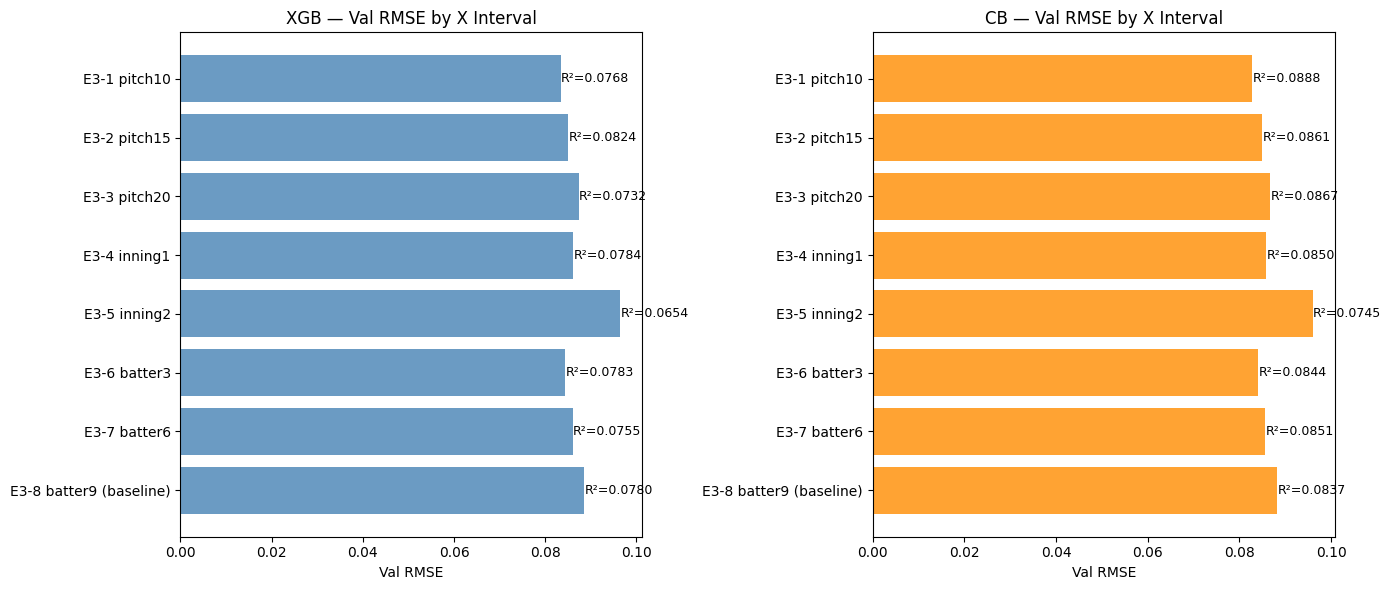

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, model, color in zip(axes, ['xgb', 'cb'], ['steelblue', 'darkorange']):
    rmse_col = f'{model}_val_rmse'
    r2_col   = f'{model}_val_r2'
    bars = ax.barh(summary['name'], summary[rmse_col], color=color, alpha=0.8)
    ax.set_xlabel('Val RMSE')
    ax.set_title(f'{model.upper()} — Val RMSE by X Interval')
    ax.invert_yaxis()
    for bar, r2 in zip(bars, summary[r2_col]):
        ax.text(bar.get_width() + 0.0001, bar.get_y() + bar.get_height()/2,
                f'R²={r2:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

## 4. mode별 트렌드

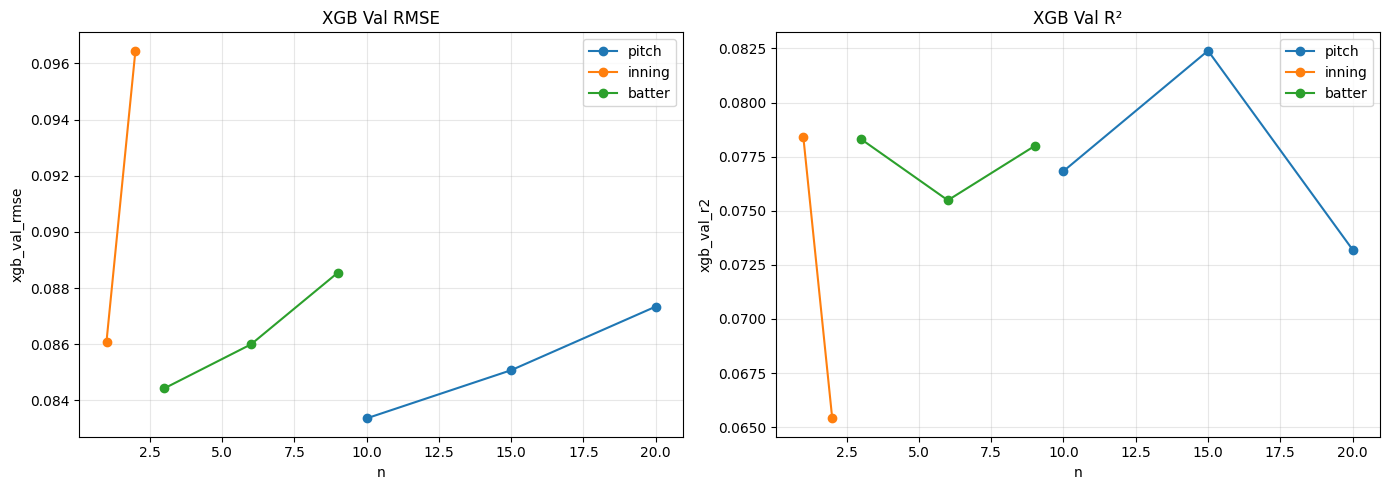

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric, title in zip(axes,
                              ['xgb_val_rmse', 'xgb_val_r2'],
                              ['XGB Val RMSE', 'XGB Val R²']):
    for mode in summary['mode'].unique():
        sub = summary[summary['mode'] == mode].sort_values('n')
        ax.plot(sub['n'], sub[metric], 'o-', label=mode)
    ax.set_xlabel('n')
    ax.set_ylabel(metric)
    ax.set_title(title)
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 5. 최적 X구간 확정

In [7]:
best_xgb = summary.loc[summary['xgb_val_rmse'].idxmin()]
best_cb  = summary.loc[summary['cb_val_rmse'].idxmin()]

print(f'XGBoost 최적: {best_xgb["name"]} (Val RMSE={best_xgb["xgb_val_rmse"]:.4f}, R²={best_xgb["xgb_val_r2"]:.4f})')
print(f'CatBoost 최적: {best_cb["name"]} (Val RMSE={best_cb["cb_val_rmse"]:.4f}, R²={best_cb["cb_val_r2"]:.4f})')

XGBoost 최적: E3-1 pitch10 (Val RMSE=0.0834, R²=0.0768)
CatBoost 최적: E3-1 pitch10 (Val RMSE=0.0828, R²=0.0888)


In [8]:
# 결과 저장
out = os.path.join(OUTPUT_DIR, 'x_interval_experiment_results.csv')
summary[cols].to_csv(out, index=False)
print(f'저장 완료 → {out}')

저장 완료 → /content/drive/MyDrive/투수 컨디션 예측 ML/4_output/x_interval_experiment_results.csv
